# Stuttering Detection: Support Vector Machine (SVM) Analysis
**Course**: CS204T (Artificial Intelligence)  
**Team**: 18  
**Focus**: Linear SVM vs. Non-Linear RBF Kernels

---

## Step 1: Environment & Configuration

In [9]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data import DataManager
from src.models import LinearSVMModel, KernelSVMModel
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA

# ==========================================
# CONFIGURATION
# ==========================================
SAMPLE_LIMIT = None
STRICT_LABELS = True # Set to True to filter out ambiguous samples (Score 1 & 2)
RANDOM_SEED = 42
FEATURE_DIR = "data/features"
CSV_PATHS = [
    "Stuttering Events in Podcasts Dataset/SEP-28k_labels.csv",
    "Stuttering Events in Podcasts Dataset/fluencybank_labels.csv"
]
# ==========================================

## Step 2: Operational Mode for Data Extraction

In [ ]:
SKIP_EXTRACTION = True
FORCE_EXTRACT = False
CLEAN_START = False
NUM_CLIPS_TO_EXTRACT = None

if not SKIP_EXTRACTION or CLEAN_START or FORCE_EXTRACT:
    from src.extractors import WavLMExtractor
    extractor = WavLMExtractor("microsoft/wavlm-base")
    label_dict = DataManager.generate_label_dict(CSV_PATHS, filter_quality=True, strict=STRICT_LABELS)
    extractor.extract_from_dir(AUDIO_DIR, output_dir=FEATURE_DIR, label_dict=label_dict, limit=NUM_CLIPS_TO_EXTRACT, random_sample=True)
else:
    print("[System] Skipping extraction. Using existing data on disk.")

## Step 3: Data Loading and Preparation

In [10]:
label_dict = DataManager.generate_label_dict(CSV_PATHS, filter_quality=True, strict=STRICT_LABELS)
manager = DataManager(None, None)

X, y = manager.load_from_folders(os.path.join(FEATURE_DIR, "fluent"), os.path.join(FEATURE_DIR, "disfluent"), limit=SAMPLE_LIMIT, label_dict=label_dict)

X_train, X_val, X_test, y_train, y_val, y_test = manager.get_splits(test_size=0.15, val_size=0.15)
X_train_bal, y_train_bal = manager.balance_data(X_train, y_train, strategy="oversample")

# PREPROCESS (Fit on train, transform on val/test)
X_train_final = manager.preprocess(X_train_bal, method="standard", fit=True)
X_val_final = manager.preprocess(X_val, fit=False)
X_test_final = manager.preprocess(X_test, fit=False)

print(f"Data Loaded: {len(X)} samples.")
manager.analyze_distribution()

[DataManager] Quality Filter: Removed 3938 low-quality samples.
[DataManager] Smart Load: Pre-selected 5000 fluent and 5000 disfluent files.
Data Loaded: 10000 samples.
--- Data Distribution ---
Fluent (0): 5000 (50.0%)
Disfluent (1): 5000 (50.0%)
Total: 10000


## Step 4: Model 1 - Linear SVM (Baseline)

In [11]:
lin_svm = LinearSVMModel("Linear_SVM_Baseline")
lin_svm.train(X_train_final, y_train_bal)
print("Evaluating Linear SVM Baseline:")
lin_svm.evaluate(X_test_final, y_test)

[Model: Linear_SVM_Baseline] Initialized.
[Linear_SVM_Baseline] Training with Linear Margin (C=1.0)...
Evaluating Linear SVM Baseline:

--- Evaluation: Linear_SVM_Baseline ---
Accuracy: 0.6733
Precision: 0.6946
Recall: 0.6187
F1: 0.6544

Confusion Matrix (Binary):
               Predicted: Fluent(0)  Predicted: Stutter(1)
True: Fluent(0)      546             204            
True: Stutter(1)     286             464            


{'accuracy': 0.6733333333333333,
 'precision': 0.6946107784431138,
 'recall': 0.6186666666666667,
 'f1': 0.6544428772919605,
 'confusion_matrix': array([[546, 204],
        [286, 464]])}

## Step 5: Model 2 - RBF Kernel SVM (Baseline)

In [12]:
rbf_svm = KernelSVMModel("RBF_SVM_Baseline", kernel="rbf")
rbf_svm.train(X_train_final, y_train_bal)
print("Evaluating RBF SVM Baseline:")
rbf_svm.evaluate(X_test_final, y_test)

[Model: RBF_SVM_Baseline] Initialized.
[RBF_SVM_Baseline] Training with RBF Kernel (C=1.0)...
Evaluating RBF SVM Baseline:

--- Evaluation: RBF_SVM_Baseline ---
Accuracy: 0.7020
Precision: 0.7572
Recall: 0.5947
F1: 0.6662

Confusion Matrix (Binary):
               Predicted: Fluent(0)  Predicted: Stutter(1)
True: Fluent(0)      607             143            
True: Stutter(1)     304             446            


{'accuracy': 0.702,
 'precision': 0.7572156196943973,
 'recall': 0.5946666666666667,
 'f1': 0.666168782673637,
 'confusion_matrix': array([[607, 143],
        [304, 446]])}

## Step 6: Optimized Hyperparameter Tuning (Kernel SVM)
Using `PredefinedSplit` to tune C and Gamma against the real-world validation distribution.

In [13]:
print("--- [STARTING EXPANDED SVM HYPERTUNING] ---")

# 1. Combine Train + Val and create split indices
X_combined = np.vstack((X_train_final, X_val_final))
y_combined = np.hstack((y_train_bal, y_val))
test_fold = np.hstack((
    np.full(len(X_train_final), -1),
    np.full(len(X_val_final), 0)
))
pds = PredefinedSplit(test_fold=test_fold)

# 2. Expanded Grid Search
# We broaden the ranges and add the Polynomial kernel to see if we can break the 71% ceiling
svm_grid = [
    {
        "C": [0.1, 1, 10, 100, 1000],
        "gamma": ["scale", "auto", 1e-4, 1e-3, 0.01, 0.1, 1],
        "kernel": ["rbf"]
    },
    {
        "C": [0.1, 1, 10, 100],
        "kernel": ["poly"],
        "degree": [2, 3],
        "gamma": ["scale"]
    }
]

gs_svm = GridSearchCV(SVC(random_state=RANDOM_SEED), svm_grid, cv=pds, scoring="accuracy", n_jobs=-1, verbose=1)
gs_svm.fit(X_combined, y_combined)

print(f"Best SVM Params: {gs_svm.best_params_}")
print(f"Best Val Accuracy: {gs_svm.best_score_:.4f}")

--- [STARTING EXPANDED SVM HYPERTUNING] ---
Fitting 1 folds for each of 43 candidates, totalling 43 fits
Best SVM Params: {'C': 10, 'gamma': 0.0001, 'kernel': 'rbf'}
Best Val Accuracy: 0.7247


## Step 7: Error Analysis (Visual Heatmaps)

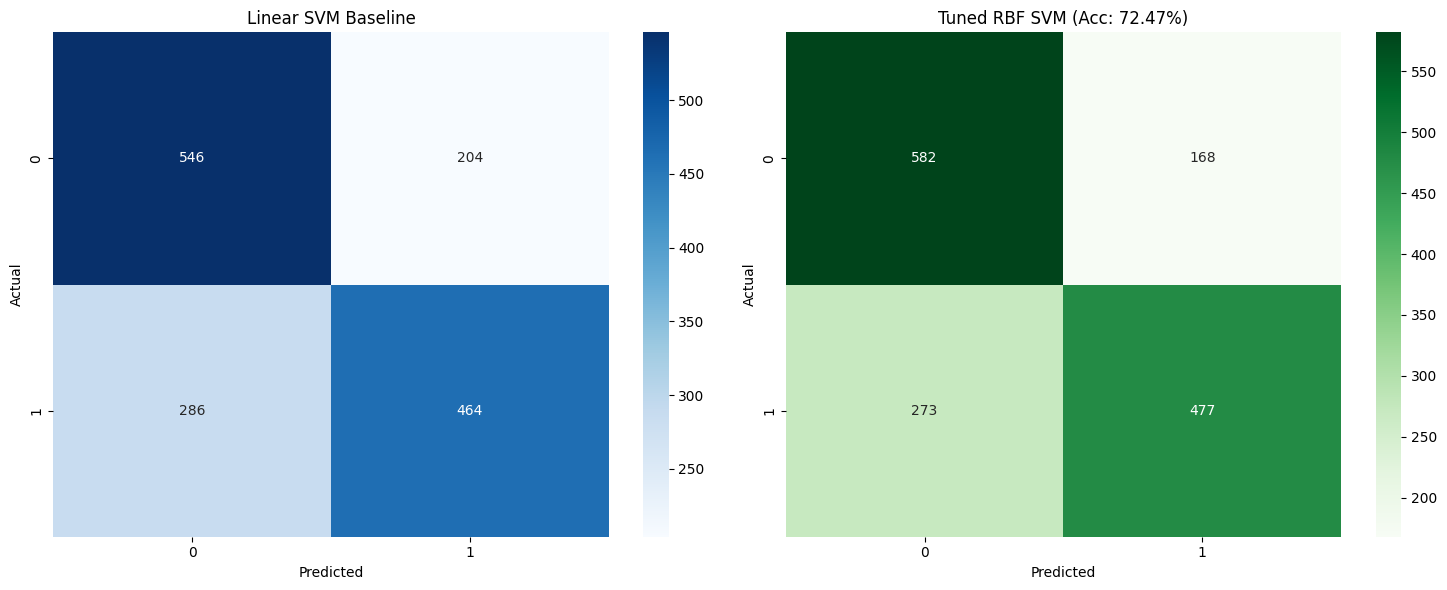

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Linear SVM CM
y_pred_lin = lin_svm.predict(X_test_final)
cm_lin = confusion_matrix(y_test, y_pred_lin)
sns.heatmap(cm_lin, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Linear SVM Baseline")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Tuned Kernel SVM CM
y_pred_tuned = gs_svm.best_estimator_.predict(X_test_final)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title(f"Tuned RBF SVM (Acc: {gs_svm.best_score_:.2%})")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Step 8: Comparative Decision Boundaries
Visualizing how the RBF kernel handles non-linearity compared to the linear margin.

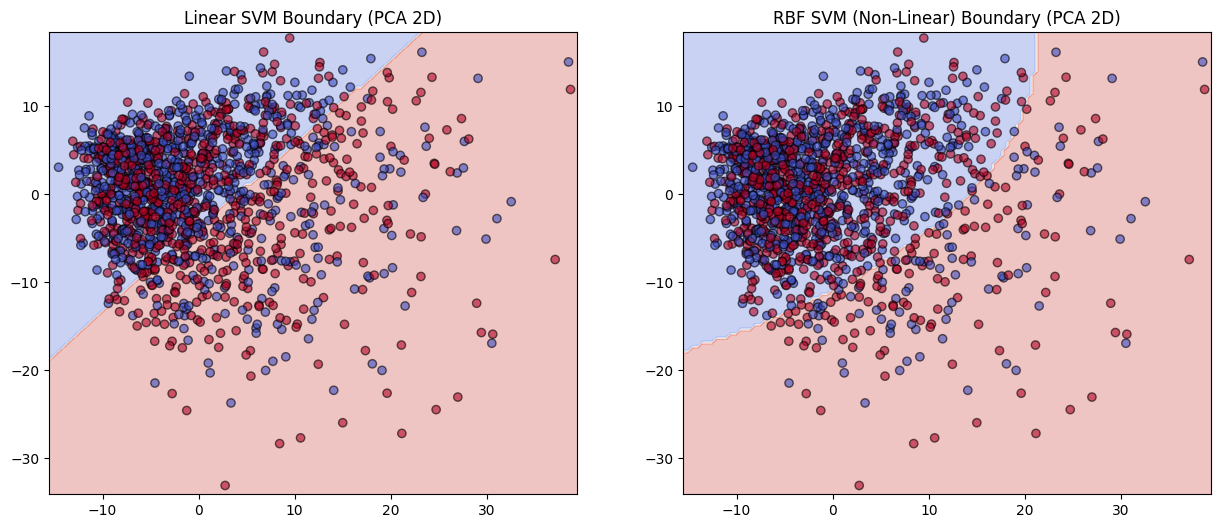

In [15]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test_final)

# Create mesh grid with coarser step for faster plotting
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5), np.arange(y_min, y_max, 0.5))

plt.figure(figsize=(15, 6))

# Subplot 1: Linear SVM
plt.subplot(1, 2, 1)
Z_lin = lin_svm.model.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
Z_lin = Z_lin.reshape(xx.shape)
plt.contourf(xx, yy, Z_lin, alpha=0.3, cmap="coolwarm")
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_test, edgecolors="k", cmap="coolwarm", alpha=0.6)
plt.title("Linear SVM Boundary (PCA 2D)")

# Subplot 2: Tuned RBF SVM
plt.subplot(1, 2, 2)
Z_rbf = gs_svm.best_estimator_.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
Z_rbf = Z_rbf.reshape(xx.shape)
plt.contourf(xx, yy, Z_rbf, alpha=0.3, cmap="coolwarm")
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_test, edgecolors="k", cmap="coolwarm", alpha=0.6)
plt.title("RBF SVM (Non-Linear) Boundary (PCA 2D)")

plt.show()

## Step 9: Save Best SVM Model

In [16]:
import joblib
os.makedirs("models", exist_ok=True)
joblib.dump(gs_svm.best_estimator_, "models/svm_rbf_best.pkl")
print("[System] Best SVM model saved to disk.")

[System] Best SVM model saved to disk.
